# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 12     |  |
| :-------------|:-------------|
| Querijn Sanson| 6562507 |
| Sriman Patlolla| 6393829 |
| Daniel Ian Roelse| 6527892 |

| Planning Groep: 12     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: sanity check |11:30|
| Mijlpaal 2: Criteria opgesteld | 12:30 |
| Mijlpaal 3: Eerste kalibratie meting gedaan| 14:30 |
| Mijlpaal 4: concluderende kalibratie meting | 15:15 |
| Mijlpaal 4: aantonen leerdoelen | 16:30 |
| Mijlpaal 5: controleren, evalueren, inleveren en feedback |17:30|
| Pauze 1| 12:30-13:30 |
| Pauze 2| 16:00-16:15 |

## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

![Alt](Afbeelding_D.jpg "analyse: ideeen")
![Alt](Afbeelding_Sr.jpg "analyse: ideeen")
![Alt](IMG_6424.jpeg "analyse: ideeen")

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|LDR | toepassing Straatverlichting | Licht aan tussen een flux van 40-50 lux en blijft daaronder aan, daarboven uit. Licht niet aan tussen 9-17 h. Afwezigheid van licht moet een minuut duren|
|Druksensor | Stoelverwarming | Moet bij gewicht tussen 30-40 kg en alles daarboven aan. Handmatig uit te zetten en temperatuur aan te passen. Gewicht minimaal een minuut op de stoel |
|Thermosensor | Slim temperatuurbehoud bij pasteurisatie | verwarming aan bij 62-64 graden celsius en daaronder en verkoeling aan bij 65-67 graden celsius en daarboven. Na een half uur stopt verwarming en gaat een alarm af. Sensor moet steriel zijn. Moet de temperatuur van de melk meten en niet de pan |

Groep 12 heeft gekozen voor sensor LDR. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Licht kort toe wat er in de foto te zien is.
 ![Alt](Afbeelding_schets.jpg "schets student")

In onze meetopstelling wordt een LDR gebruikt die is aangesloten op de arduino. Deze LDR wordt naast de lux-meter van een telefoon geplaatst. Vervolgens zal met een stuk karton de hoeveelheid licht die binnenkomt worden gevarieerd. Vervolgens wordt dan gekeken wat de waarden zijn die de arduino geeft om zo de sensor te kalibreren.

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen?
De lux 
2. Over welk bereik ga je deze variabelen veranderen?
tussen 20-200 lux
3. Wat ga je allemaal meten?
De lux met phyphox en de hoeveel bits die de arduino aangeeft 
4. Hoeveel metingen ga je doen?
10
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?
ja


## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Licht kort toe wat er in de foto te zien is.
 ![Alt](Afbeelding_opstelling.jpg "meetopstelling student")

Na eerste experiment kwamen we erachter dat de telefoon alleen lux vanaf de bovenkant meet en de LDR vanaf de zijkant. Daarom hebben we deze meetopstelling in een schoenendoos geplaatst om zo de lichtstralen vanaf de zijkant zoveel mogelijk te minimaliseren 

## *Opdracht 6*: Meten en fitten, Leerdoel

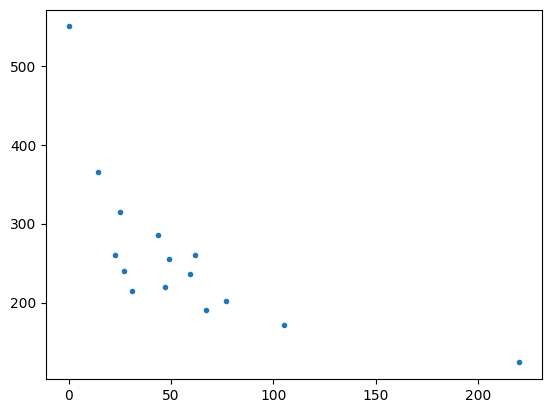

In [1]:
# Zet hier jouw data in een voor jou handig formaat
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
lux=np.array([0,22.5,59.5,105,27,220,14.5,25,31,49,43.5,61.5,77,67,47])
bits=np.array([550,260,236,172,240,124,365,315,215,255,285,260,202,190,220])
plt.plot(lux,bits,'.')


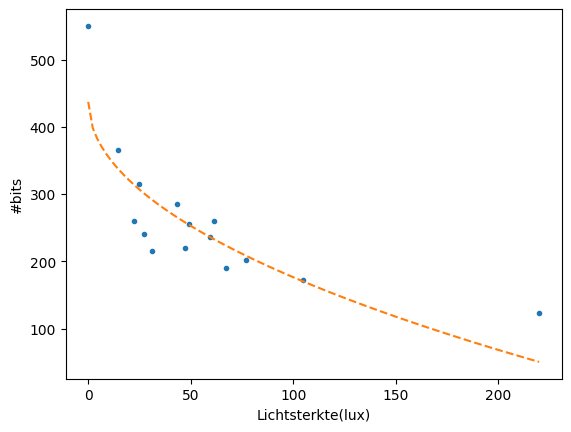

De waarden voor a, b zijn: [437.13086516  26.06404648]
De onzekerheden voor a, b zijn: [31.93266333  4.24325452]
Bij deze hoeveelheid bits is de lux 45 en gaat het licht uit of aan: 262.28792603403565
Onzekerheid in bits: 0.17843927256370037
Waarde in bits bij 45 lx 252.83022501458888
De onzekerheid van de lux is ongeveer: 0.09189807459251398 lx


In [9]:
# Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum.
%matplotlib inline

def func(x,a,b):
    # return a+b*np.exp(-c*(x-d))
    return a-b*np.sqrt(1*(x))

popt, pcov = curve_fit(func, lux, bits, p0=[400,20],maxfev=500000)

x_test=np.linspace(np.min(lux),np.max(lux),100)
y_test=func(x_test,*popt)

plt.figure()
plt.plot(lux,bits,'.', label="Data")
plt.plot(x_test,y_test,'--')
# plt.ylim(0,700)
plt.xlabel("Lichtsterkte(lux)")
plt.ylabel("#bits")
plt.show()

a,b= popt
da,db = np.sqrt(np.diag(pcov))
onz_y_test=np.sqrt((da/a)**2 + (db/b)**2 )

print("De waarden voor a, b zijn:",popt)
print("De onzekerheden voor a, b zijn:",np.sqrt(np.diag(pcov)))
print("Bij deze hoeveelheid bits is de lux 45 en gaat het licht uit of aan:",func(45,*popt))
print("Onzekerheid in bits:",onz_y_test)
print("Waarde in bits bij 45 lx",func(50,*popt))
lux_a=((a-(-onz_y_test + func(45,*popt)))/b)**2
print("De onzekerheid van de lux is ongeveer:",lux_a-45,"lx")


## *Opdracht 7*: Iteratie nodig?

Wij gaan niet itereren. 

## *Opdracht 8*: Conclusie, leerdoel

De lantaarnpaal moest aangaan tussen een lux van 40 en 50. Daarvoor zou er bij een lux van 45 een fout moeten zijn van 5 of kleiner. Uit de grafiek wordt duidelijk dat deze fout alleen groter is dan 5 lux en dus dat deze LDR aan de hand van deze kalibratie niet bruikbaar is om straatlicht aan te krijgen bij schemerlicht

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Licht kort toe wat er in de foto te zien is.
 ![Alt](Afbeelding_schets.jpg "schets student")

In onze meetopstelling wordt een LDR gebruikt die is aangesloten op de arduino. Deze LDR wordt naast de lux-meter van een telefoon geplaatst. Vervolgens zal met een stuk karton de hoeveelheid licht die binnenkomt worden gevarieerd. Vervolgens wordt dan gekeken wat de waarden zijn die de arduino geeft om zo de sensor te kalibreren.

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Licht kort toe wat er in de foto te zien is.
 ![Alt](Afbeelding_opstelling.jpg "meetopstelling student")

Na eerste experiment kwamen we erachter dat de telefoon alleen lux vanaf de bovenkant meet en de LDR vanaf de zijkant. Daarom hebben we deze meetopstelling in een schoenendoos geplaatst om zo de lichtstralen vanaf de zijkant zoveel mogelijk te minimaliseren 

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|LDR | toepassing Straatverlichting | Licht aan tussen een flux van 40-50 lux en blijft daaronder aan, daarboven uit. Licht niet aan tussen 9-17 h. Afwezigheid van licht moet een minuut duren|
|Druksensor | Stoelverwarming | Moet bij gewicht tussen 30-40 kg en alles daarboven aan. Handmatig uit te zetten en temperatuur aan te passen. Gewicht minimaal een minuut op de stoel |
|Thermosensor | Slim temperatuurbehoud bij pasteurisatie | verwarming aan bij 62-64 graden celsius en daaronder en verkoeling aan bij 65-67 graden celsius en daarboven. Na een half uur stopt verwarming en gaat een alarm af. Sensor moet steriel zijn. Moet de temperatuur van de melk meten en niet de pan |

Groep 12 heeft gekozen voor sensor LDR. 

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Licht kort toe wat er in de foto te zien is.
 ![Alt](Afbeelding_schets.jpg "schets student")

In onze meetopstelling wordt een LDR gebruikt die is aangesloten op de arduino. Deze LDR wordt naast de lux-meter van een telefoon geplaatst. Vervolgens zal met een stuk karton de hoeveelheid licht die binnenkomt worden gevarieerd. Vervolgens wordt dan gekeken wat de waarden zijn die de arduino geeft om zo de sensor te kalibreren.

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Licht kort toe wat er in de foto te zien is.
 ![Alt](Afbeelding_opstelling.jpg "meetopstelling student")

Na eerste experiment kwamen we erachter dat de telefoon alleen lux vanaf de bovenkant meet en de LDR vanaf de zijkant. Daarom hebben we deze meetopstelling in een schoenendoos geplaatst om zo de lichtstralen vanaf de zijkant zoveel mogelijk te minimaliseren 


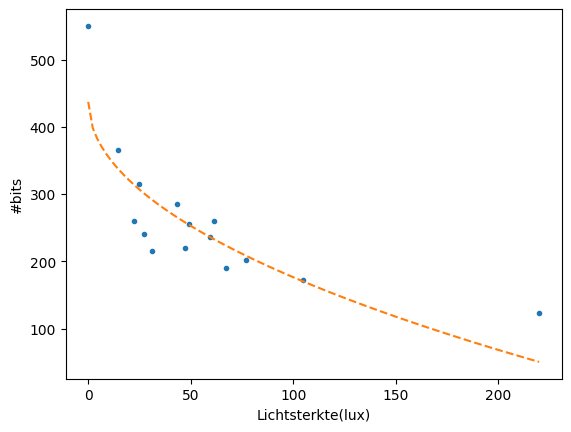

De waarden voor a, b zijn: [437.13086516  26.06404648]
De onzekerheden voor a, b zijn: [31.93266333  4.24325452]
Bij deze hoeveelheid bits is de lux 45 en gaat het licht uit of aan: 262.28792603403565
Onzekerheid in bits: 0.17843927256370037
Waarde in bits bij 45 lx 252.83022501458888
De onzekerheid van de lux is ongeveer: 0.09189807459251398 lx


In [10]:
# Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum.
%matplotlib inline

def func(x,a,b):
    # return a+b*np.exp(-c*(x-d))
    return a-b*np.sqrt(1*(x))

popt, pcov = curve_fit(func, lux, bits, p0=[400,20],maxfev=500000)

x_test=np.linspace(np.min(lux),np.max(lux),100)
y_test=func(x_test,*popt)

plt.figure()
plt.plot(lux,bits,'.', label="Data")
plt.plot(x_test,y_test,'--')
# plt.ylim(0,700)
plt.xlabel("Lichtsterkte(lux)")
plt.ylabel("#bits")
plt.show()

a,b= popt
da,db = np.sqrt(np.diag(pcov))
onz_y_test=np.sqrt((da/a)**2 + (db/b)**2 )

print("De waarden voor a, b zijn:",popt)
print("De onzekerheden voor a, b zijn:",np.sqrt(np.diag(pcov)))
print("Bij deze hoeveelheid bits is de lux 45 en gaat het licht uit of aan:",func(45,*popt))
print("Onzekerheid in bits:",onz_y_test)
print("Waarde in bits bij 45 lx",func(50,*popt))
lux_a=((a-(-onz_y_test + func(45,*popt)))/b)**2
print("De onzekerheid van de lux is ongeveer:",lux_a-45,"lx")

## *Opdracht 8*: Conclusie, leerdoel

De lantaarnpaal moest aangaan tussen een lux van 40 en 50. Daarvoor zou er bij een lux van 45 een fout moeten zijn van 5 of kleiner. Uit de grafiek wordt duidelijk dat deze fout alleen groter is dan 5 lux en dus dat deze LDR aan de hand van deze kalibratie niet bruikbaar is om straatlicht aan te krijgen bij schemerlicht